# Text-to-Brain Metrics v2

This notebook evaluates only the text-to-brain direction from the old metrics v2 notebook. It reports Pearson correlation, Spearman correlation, percentile Dice, spin-test p-values when dependencies are available, and threshold-sensitivity plots.

This notebook is configured to run the full available networks, PubMed test, and NeuroVault evaluation sets by default. Spin tests are disabled by default because fitting surface rotations for every full-dataset sample is very slow; set `SPIN_USE_NEUROMAPS = True` for smaller spin-test runs.

In [15]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics import (
    pearson_correlation,
    dice_percentile,
    nct_dice_spin_test_surface,
    mni152_to_fsaverage_arrays,
    precompute_spin_permutations,
)

In [16]:
MAX_T2B = 40        # full available networks, PubMed test, and NeuroVault sets
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True

DICE_PCT = 90
DICE_SENSITIVITY_PCTS = [80, 85, 90, 95]
SPIN_USE_NEUROMAPS = True  # keep False for full-dataset runs; spin tests are very slow
SPIN_TEST_N_PERM = 1000
SPIN_TEST_RANDOM_STATE = 13
SPIN_FSAVERAGE_DENSITY = "41k"
SPIN_TRANSFORM_METHOD = "linear"

OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
nvlm = NeuroVLM()
masker = load_masker()

if SPIN_USE_NEUROMAPS:
    precompute_spin_permutations(
        density=SPIN_FSAVERAGE_DENSITY,
        n_perm=SPIN_TEST_N_PERM,
        random_state=SPIN_TEST_RANDOM_STATE,
    )
    print(f"Precomputed {SPIN_TEST_N_PERM} fsaverage {SPIN_FSAVERAGE_DENSITY} spin permutations.")

print("Ready.")


/Users/borng/code/lab_work/neurovlm/.conda/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Precomputed 1000 fsaverage 41k spin permutations.
Ready.


In [18]:
def load_network_test_set_labels_table():
    try:
        return load_dataset("network_test_set_labels"), "huggingface:neurovlm/embedded_text/network_test_set_labels.csv"
    except Exception as hf_error:
        candidates = [
            Path("network_test_set_labels.csv"),
            Path("docs/03_evaluation/network_test_set_labels.csv"),
            Path.cwd() / "network_test_set_labels.csv",
            Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
        ]
        for candidate in candidates:
            if candidate.exists():
                return pd.read_csv(candidate), str(candidate.resolve())
        raise FileNotFoundError(
            "Could not load network_test_set_labels.csv from Hugging Face or local paths. "
            "Upload it to neurovlm/embedded_text as network_test_set_labels.csv. "
            f"Hugging Face error: {hf_error}"
        )


network_labels_df, NETWORK_TEST_SET_SOURCE = load_network_test_set_labels_table()
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_SOURCE}")
display(network_info[["network_key", "display", "short_definition"]])

Loaded 8 canonical network labels from huggingface:neurovlm/embedded_text/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [19]:
def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
network_label_rows = (
    network_labels_df
    .drop_duplicates("raw_network_label")
    .set_index("raw_network_label")
)

networks_data = {}
for atlas_name, atlas_latents in all_net_latents.items():
    if not hasattr(atlas_latents, "items"):
        continue
    for raw_label, latent in atlas_latents.items():
        if raw_label not in network_label_rows.index:
            continue
        row = network_label_rows.loc[raw_label]
        sample_name = f"{atlas_name}:{raw_label}"
        networks_data[sample_name] = {
            "latent": latent,
            "short_gt": _normalize_expected_text(row["short_definition"]),
            "long_gt": _normalize_expected_text(row["long_definition"]),
            "network_key": row["network_key"],
            "display": row["network_name"],
            "atlas": atlas_name,
            "raw_network_label": raw_label,
        }

print(f"Networks loaded: {len(networks_data)} labeled maps across {len(all_net_latents)} atlases")
display(pd.DataFrame([
    {"sample": name, "network_key": d["network_key"], "display": d["display"]}
    for name, d in networks_data.items()
]).head())

Networks loaded: 119 labeled maps across 10 atlases


,sample,network_key,display
0,Du:CG-OP,cingulo_opercular,Cingulo-Opercular
1,Du:DN-B,default_mode,Default Mode
2,Du:SMOT-B,motor,Motor
3,Du:AUD,auditory,Auditory
4,Du:PM-PPr,motor,Motor


In [20]:
df_pubs = load_dataset("pubmed_text")
if "test" not in df_pubs.columns:
    raise ValueError("pubmed_text must include a boolean 'test' column for PubMed evaluation.")
df_test = df_pubs[df_pubs["test"].fillna(False).astype(bool)].reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_title_col = "name" if "name" in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)
mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]
pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row = pmid_to_row.loc[pmid]
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "short_gt": str(row[_title_col]) if _title_col in row.index else "",
        "long_gt": str(row[_abstract_col]) if _abstract_col in row.index else "",
    })

pubmed_eval = pubmed_data[:MAX_T2B] if MAX_T2B else pubmed_data
print(f"PubMed samples: {len(pubmed_eval)} / {len(pubmed_data)}")

PubMed samples: 40 / 2987


In [21]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue
    neurovault_data.append({
        "doi": doi,
        "latent": nv_latents[int(img_indices[0])],
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
    })

neurovault_eval = neurovault_data[:MAX_T2B] if MAX_T2B else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")

NeuroVault samples: 40 / 312


In [22]:
def run_t2b(name, text_input, true_latent):
    try:
        gen_result = nvlm.text(text_input).to_brain(head="mse")
        nifti_pred = gen_result.to_nifti(index=0)
        brain_pred = masker.transform(nifti_pred).ravel().astype("float32")

        dec = gen_result.decoder
        dec_device = next(dec.parameters()).device
        lat = true_latent
        if lat.dim() == 1:
            lat = lat.unsqueeze(0)
        with torch.no_grad():
            brain_true = torch.sigmoid(dec(lat.to(dec_device))).squeeze(0).cpu().numpy()
        nifti_true = masker.inverse_transform(brain_true.reshape(1, -1))

        pearson_r = float(pearson_correlation(brain_true, brain_pred))
        spearman_rho, _ = spearmanr(brain_true.ravel(), brain_pred.ravel())
        dice_val = dice_percentile(brain_pred, brain_true, pct=DICE_PCT)
        dice_method = "volume_masker_percentile"
        pred_lh = pred_rh = true_lh = true_rh = None
        spin_p_value = np.nan
        spin_method = "not_run"
        spin_significant = False

        if SPIN_USE_NEUROMAPS:
            try:
                pred_lh, pred_rh = mni152_to_fsaverage_arrays(nifti_pred, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                true_lh, true_rh = mni152_to_fsaverage_arrays(nifti_true, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                nct = nct_dice_spin_test_surface(
                    pred_lh, pred_rh, true_lh, true_rh,
                    pct=DICE_PCT,
                    n_perm=SPIN_TEST_N_PERM,
                    random_state=SPIN_TEST_RANDOM_STATE,
                    density=SPIN_FSAVERAGE_DENSITY,
                )
                dice_val = nct.dice_pct
                dice_method = "surface_fsaverage_percentile_nct"
                spin_p_value = nct.spin_p_value
                spin_method = nct.spin_method
                spin_significant = nct.spin_significant
            except ImportError as e:
                spin_method = f"not_run_missing_dependency:{e.name}"
            except Exception as e:
                spin_method = f"not_run_nct_error:{type(e).__name__}: {e}"

        return {
            "name": name,
            "text_input": text_input[:120],
            "pearson_r": pearson_r,
            "spearman_rho": float(spearman_rho),
            f"dice_pct{DICE_PCT}": float(dice_val),
            "dice_method": dice_method,
            "spin_p_value": float(spin_p_value) if np.isfinite(spin_p_value) else np.nan,
            "spin_significant": bool(spin_significant),
            "spin_method": spin_method,
            "_brain_pred": brain_pred,
            "_brain_true": brain_true,
            "_pred_lh": pred_lh,
            "_pred_rh": pred_rh,
            "_true_lh": true_lh,
            "_true_rh": true_rh,
        }
    except Exception as e:
        print(f"[T2B error] {name}: {type(e).__name__}: {e}")
        return None

In [23]:
t2b_frames = []

if RUN_NETWORKS:
    records = []
    for net_name, d in tqdm(networks_data.items(), desc="Networks T2B"):
        rec = run_t2b(net_name, d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_net_df = pd.DataFrame(records)
    t2b_net_df["dataset"] = "networks"
    t2b_frames.append(t2b_net_df)

if RUN_PUBMED:
    records = []
    for d in tqdm(pubmed_eval, desc="PubMed T2B"):
        rec = run_t2b(str(d["pmid"]), d["short_gt"] + " [SEP] " + d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_pubmed_df = pd.DataFrame(records)
    t2b_pubmed_df["dataset"] = "pubmed"
    t2b_frames.append(t2b_pubmed_df)

if RUN_NEUROVAULT:
    records = []
    for d in tqdm(neurovault_eval, desc="NeuroVault T2B"):
        rec = run_t2b(str(d["doi"]), d["short_gt"] + " [SEP] " + d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_nv_df = pd.DataFrame(records)
    t2b_nv_df["dataset"] = "neurovault"
    t2b_frames.append(t2b_nv_df)

t2b_all = pd.concat(t2b_frames, ignore_index=True)
t2b_all.to_csv(OUTPUT_DIR / "text_to_brain_metrics_v2.csv", index=False)
t2b_all.head()

Networks T2B:   0%|          | 0/119 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


PubMed T2B:   0%|          | 0/40 [00:00<?, ?it/s]

NeuroVault T2B:   0%|          | 0/40 [00:00<?, ?it/s]

,name,text_input,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,_brain_pred,_brain_true,_pred_lh,_pred_rh,_true_lh,_true_rh,dataset
0,Du:CG-OP,The cingulo-opercular network includes dorsal ...,0.313852,0.567137,0.318931,surface_fsaverage_percentile_nct,0.001998,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[3.2545968e-06, 0.022498814, 0.023728335, 4.80...","[1.3146594e-17, 1.0277472e-06, 1.0417248e-05, ...","[0.02697701, 0.026646242, 0.06443043, 0.041302...","[0.032546982, 0.07813092, 0.019515112, 0.06247...","[0.0015657404, 0.00045247586, 0.37159526, 0.00...","[0.0038916098, 7.685055e-05, 0.00090343785, 0....",networks
1,Du:DN-B,The default mode network includes medial prefr...,0.333324,0.631819,0.414378,surface_fsaverage_percentile_nct,0.002997,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[1.5073856e-06, 0.041484848, 0.039975416, 3.24...","[4.7605947e-20, 0.018851157, 0.0037589371, 6.9...","[0.011652597, 0.01869179, 0.023020802, 0.05054...","[0.020478254, 0.042466007, 0.0093206465, 0.030...","[2.2295095e-09, 2.8574766e-08, 1.3823765e-06, ...","[8.0128797e-07, 7.139549e-07, 1.3709233e-07, 8...",networks
2,Du:SMOT-B,The motor or somatomotor network includes prim...,0.197300,0.562804,0.249725,surface_fsaverage_percentile_nct,0.185814,False,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[9.712928e-07, 0.0045603802, 0.006362473, 1.43...","[3.714492e-20, 3.1787724e-07, 7.767891e-07, 5....","[0.2362361, 0.022776745, 0.15076149, 0.0096546...","[0.15418983, 0.051781975, 0.068913504, 0.01897...","[0.0004506922, 9.519958e-09, 0.00040893696, 7....","[0.00066493853, 3.493841e-07, 0.5425452, 2.594...",networks
3,Du:AUD,The auditory network includes primary auditory...,0.642937,0.699131,0.802026,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[2.0208913e-06, 0.17914301, 0.17343724, 4.1845...","[1.966833e-25, 0.00014512522, 0.0003801403, 5....","[0.011207284, 0.0050929696, 0.031968236, 0.015...","[0.014900311, 0.019930176, 0.03411155, 0.00880...","[9.544638e-11, 7.386878e-08, 9.257005e-10, 2.7...","[6.825629e-09, 6.751385e-08, 4.592297e-06, 4.4...",networks
4,Du:PM-PPr,The motor or somatomotor network includes prim...,0.263603,0.505386,0.394727,surface_fsaverage_percentile_nct,0.048951,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[9.712928e-07, 0.0045603802, 0.006362473, 1.43...","[7.196587e-21, 1.3443684e-09, 1.9521172e-08, 1...","[0.2362361, 0.022776745, 0.15076149, 0.0096546...","[0.15418983, 0.051781975, 0.068913504, 0.01897...","[0.04481251, 0.20633507, 0.000111464455, 7.052...","[0.22002053, 0.13150863, 0.008307582, 7.946913...",networks


In [24]:
dice_col = f"dice_pct{DICE_PCT}"
metric_cols = ["pearson_r", "spearman_rho", dice_col, "spin_p_value"]
summary = t2b_all.groupby("dataset")[metric_cols].agg(["mean", "std", "count"]).round(3)
display(summary)
display(t2b_all.groupby("dataset")["spin_significant"].sum().rename("n_spin_p_lt_0_05"))
display(t2b_all.groupby(["dataset", "spin_method"]).size().rename("n"))

pearson_r              spearman_rho              dice_pct90         \
                mean    std count         mean    std count       mean    std   
dataset                                                                         
networks       0.362  0.184   119        0.558  0.144   119      0.443  0.189   
neurovault     0.141  0.157    40        0.356  0.218    40      0.192  0.157   
pubmed         0.381  0.205    40        0.531  0.260    40      0.335  0.176   

                 spin_p_value               
           count         mean    std count  
dataset                                     
networks     119        0.065  0.145   119  
neurovault    40        0.323  0.332    40  
pubmed        40        0.132  0.260    40

dataset
networks      92
neurovault    13
pubmed        29
Name: n_spin_p_lt_0_05, dtype: int64

dataset     spin_method                                      
networks    neuromaps_mni152_to_fsaverage_41k+brainspace_spin    119
neurovault  neuromaps_mni152_to_fsaverage_41k+brainspace_spin     40
pubmed      neuromaps_mni152_to_fsaverage_41k+brainspace_spin     40
Name: n, dtype: int64

In [25]:
def _sensitivity_rows_for_df(df, dataset, pcts=DICE_SENSITIVITY_PCTS):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{dataset} Dice sensitivity"):
        for pct in pcts:
            has_surface = all(row.get(k) is not None for k in ["_pred_lh", "_pred_rh", "_true_lh", "_true_rh"])
            spin_p = np.nan
            spin_sig = False
            method = "volume_masker_percentile"
            if has_surface:
                try:
                    nct = nct_dice_spin_test_surface(
                        row["_pred_lh"], row["_pred_rh"], row["_true_lh"], row["_true_rh"],
                        pct=pct, n_perm=SPIN_TEST_N_PERM, random_state=SPIN_TEST_RANDOM_STATE,
                        density=SPIN_FSAVERAGE_DENSITY,
                    )
                    dice_val = nct.dice_pct
                    spin_p = nct.spin_p_value
                    spin_sig = nct.spin_significant
                    method = "surface_fsaverage_percentile_nct"
                except Exception:
                    dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            else:
                dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            rows.append({
                "dataset": dataset,
                "sample": row["name"],
                "pct": pct,
                "top_fraction": (100 - pct) / 100,
                "dice": float(dice_val),
                "spin_p_value": float(spin_p) if np.isfinite(spin_p) else np.nan,
                "spin_significant": bool(spin_sig),
                "method": method,
            })
    return rows

sensitivity_records = []
for dataset, sub in t2b_all.groupby("dataset"):
    sensitivity_records.extend(_sensitivity_rows_for_df(sub.reset_index(drop=True), dataset))
t2b_sensitivity_df = pd.DataFrame(sensitivity_records)
display(t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(dice_mean=("dice", "mean"), dice_std=("dice", "std"), sig_rate=("spin_significant", "mean"), n=("sample", "count")).round(3))

networks Dice sensitivity:   0%|          | 0/119 [00:00<?, ?it/s]

neurovault Dice sensitivity:   0%|          | 0/40 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/40 [00:00<?, ?it/s]

dice_mean  dice_std  sig_rate    n
dataset    pct                                    
networks   80       0.562     0.156     0.840  119
           85       0.516     0.170     0.790  119
           90       0.443     0.189     0.773  119
           95       0.310     0.199     0.689  119
neurovault 80       0.293     0.154     0.350   40
           85       0.245     0.157     0.375   40
           90       0.192     0.157     0.325   40
           95       0.120     0.136     0.250   40
pubmed     80       0.462     0.163     0.775   40
           85       0.407     0.169     0.725   40
           90       0.335     0.176     0.725   40
           95       0.245     0.176     0.675   40

/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_85779/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_85779/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_85779/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_85779/3930137777.py:6: Matplotli

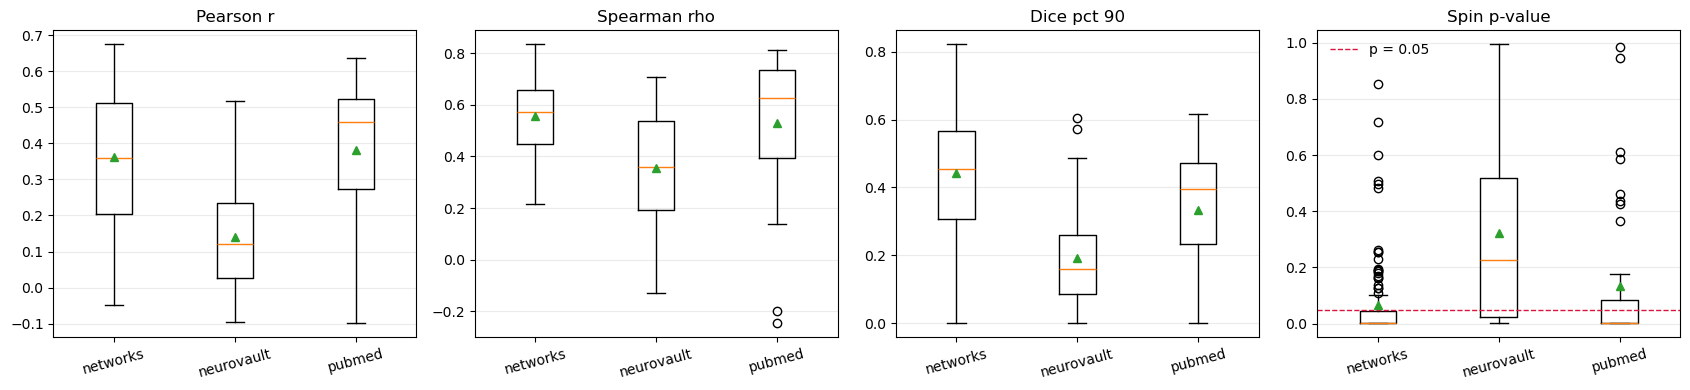

In [26]:
dice_col = f"dice_pct{DICE_PCT}"
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, metric, title in zip(axes, ["pearson_r", "spearman_rho", dice_col, "spin_p_value"], ["Pearson r", "Spearman rho", f"Dice pct {DICE_PCT}", "Spin p-value"]):
    groups = [g[metric].dropna().values for _, g in t2b_all.groupby("dataset")]
    labels = [k for k, _ in t2b_all.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    if metric == "spin_p_value":
        ax.axhline(0.05, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
        ax.legend(frameon=False)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

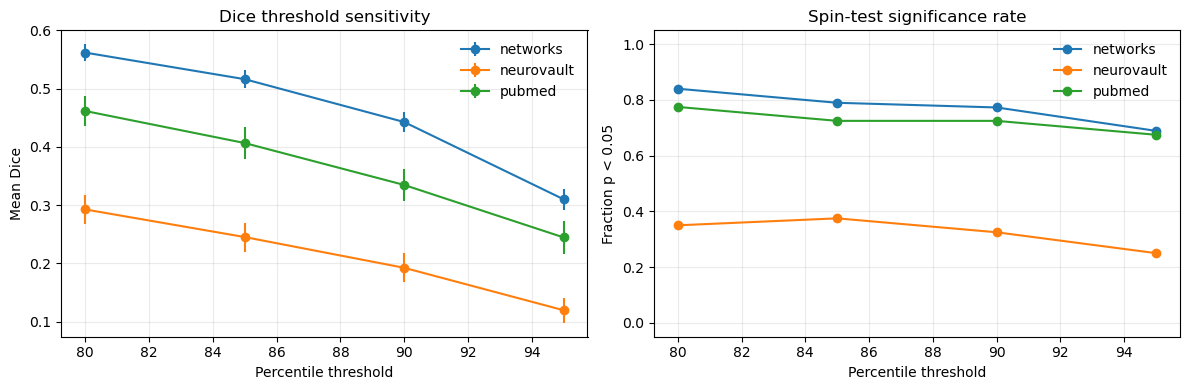

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_plot = t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(
    dice_mean=("dice", "mean"),
    dice_sem=("dice", lambda x: x.std() / np.sqrt(len(x))),
    sig_rate=("spin_significant", "mean"),
).reset_index()
for dataset, sub in summary_plot.groupby("dataset"):
    axes[0].errorbar(sub["pct"], sub["dice_mean"], yerr=sub["dice_sem"], marker="o", label=dataset)
    axes[1].plot(sub["pct"], sub["sig_rate"], marker="o", label=dataset)
axes[0].set_xlabel("Percentile threshold")
axes[0].set_ylabel("Mean Dice")
axes[0].set_title("Dice threshold sensitivity")
axes[1].set_xlabel("Percentile threshold")
axes[1].set_ylabel("Fraction p < 0.05")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Spin-test significance rate")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_pvalue_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

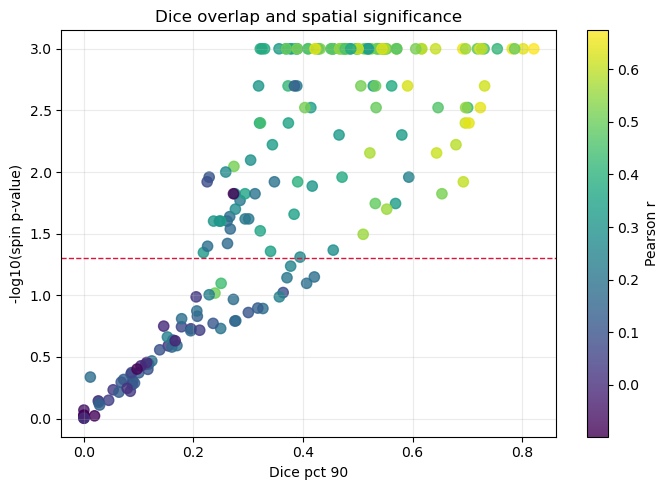

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(t2b_all[dice_col], -np.log10(t2b_all["spin_p_value"].clip(lower=1e-6)), c=t2b_all["pearson_r"], cmap="viridis", s=55, alpha=0.8)
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel(f"Dice pct {DICE_PCT}")
ax.set_ylabel("-log10(spin p-value)")
ax.set_title("Dice overlap and spatial significance")
cb = fig.colorbar(scatter, ax=ax)
cb.set_label("Pearson r")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_vs_pvalue.png", dpi=150, bbox_inches="tight")
plt.show()